# Linear Regression — Baseline Model

Linear Regression was implemented as an additional baseline model for comparison with the group's main machine-learning models.

The model uses the training and testing datasets generated by the corrected combined preprocessing pipeline:

- `final_train_processed_house_data.csv`
- `final_test_processed_house_data.csv`

The preprocessing transformations were fitted using the training data and then applied to the test data to prevent data leakage. The processed train and test datasets are used directly for model training and evaluation.


In [1]:
# ==========================================
# CELL 1 - IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# ==========================================
# CELL 2 - LOAD CORRECTED COMBINED-PIPELINE DATA
# ==========================================

train_data = pd.read_csv("final_train_processed_house_data.csv")
test_data = pd.read_csv("final_test_processed_house_data.csv")

print("Training dataset shape:", train_data.shape)
print("Testing dataset shape :", test_data.shape)

print("\nTraining data preview:")
display(train_data.head())

print("\nTest data preview:")
display(test_data.head())


Training dataset shape: (17290, 93)
Testing dataset shape : (4323, 93)

Training data preview:


,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_basement,yr_built,lat,...,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,price
0,-0.395263,-0.474451,-0.919600,0,0,4,9,-0.656310,0.404001,-1.396608,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,325000.0
1,-1.468964,-1.452583,-0.919600,0,0,3,6,-0.200433,-1.430565,-0.060172,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,257000.0
2,-0.395263,-1.452583,0.001545,0,0,3,6,-0.451165,-0.988910,-0.552847,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,228500.0
3,-0.395263,0.177636,-0.919600,0,0,4,7,1.189993,0.200160,-1.193614,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,288000.0
4,-1.468964,0.503680,0.922690,0,0,3,8,0.016109,1.219364,1.040039,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,479000.0



Test data preview:


,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_basement,yr_built,lat,...,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,price
0,0.678437,0.177636,0.92269,0,0,4,8,-0.656310,0.505921,-0.877926,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,365000.0
1,1.752138,1.155768,-0.91960,0,0,5,8,1.782634,0.200160,0.852938,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,865000.0
2,0.678437,0.503680,0.92269,0,2,3,11,-0.656310,0.879629,0.030850,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1038000.0
3,-0.395263,1.807856,0.92269,0,2,3,12,-0.656310,0.641815,1.005364,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1490000.0
4,-0.395263,0.503680,0.92269,0,0,3,9,-0.656310,1.117443,0.753969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,711000.0


## Why no preprocessing is repeated here?

The combined pipeline has already:

1. separated the target from the predictors,
2. performed the train/test split,
3. fitted `StandardScaler` using the training data only,
4. transformed the test data using the fitted training scaler,
5. fitted `OneHotEncoder` using the training data only, and
6. aligned the final train and test feature columns.

Therefore, this model notebook directly uses the exported train and test datasets to avoid introducing a new or inconsistent preprocessing setup.


In [3]:
# ==========================================
# CELL 3 - SEPARATE FEATURES AND TARGET
# ==========================================

target = "price"

X_train = train_data.drop(columns=[target])
y_train = train_data[target]

X_test = test_data.drop(columns=[target])
y_test = test_data[target]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTrain/test feature columns identical:",
      X_train.columns.equals(X_test.columns))

print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test :", X_test.isnull().sum().sum())


X_train shape: (17290, 92)
X_test shape : (4323, 92)
y_train shape: (17290,)
y_test shape : (4323,)

Train/test feature columns identical: True
Missing values in X_train: 0
Missing values in X_test : 0


## Baseline Model

Linear Regression is used as a **simple benchmark**. Its performance provides a reference point for deciding whether the group's more complex models produce a meaningful improvement on the same processed data.


In [4]:
# ==========================================
# CELL 4 - BUILD AND TRAIN LINEAR REGRESSION
# ==========================================

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression trained successfully!")


Linear Regression trained successfully!


In [5]:
# ==========================================
# CELL 5 - TEST-SET EVALUATION
# ==========================================

y_test_pred = lr_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("LINEAR REGRESSION BASELINE - TEST PERFORMANCE")
print("=" * 52)
print(f"MAE  : {test_mae:,.2f}")
print(f"RMSE : {test_rmse:,.2f}")
print(f"R²   : {test_r2:.4f}")


LINEAR REGRESSION BASELINE - TEST PERFORMANCE
MAE  : 102,711.65
RMSE : 177,708.09
R²   : 0.7911


## Evaluation Metrics

- **MAE** measures the average absolute prediction error in the target's original units.
- **RMSE** also measures prediction error but gives greater weight to larger errors.
- **R²** measures how much of the variation in house prices is explained by the model.

The test-set metrics are used as the baseline results for comparison with the group's other models.


In [6]:
# ==========================================
# CELL 6 - TRAIN VS TEST PERFORMANCE
# Check generalization / possible overfitting
# ==========================================

y_train_pred = lr_model.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

r2_gap = abs(train_r2 - test_r2)

print("TRAINING PERFORMANCE")
print("-" * 32)
print(f"MAE  : {train_mae:,.2f}")
print(f"RMSE : {train_rmse:,.2f}")
print(f"R²   : {train_r2:.4f}")

print("\nTEST PERFORMANCE")
print("-" * 32)
print(f"MAE  : {test_mae:,.2f}")
print(f"RMSE : {test_rmse:,.2f}")
print(f"R²   : {test_r2:.4f}")

print("\nGENERALIZATION CHECK")
print("-" * 32)
print(f"Absolute R² gap: {r2_gap:.4f}")

if train_r2 > test_r2 and r2_gap >= 0.10:
    print("Observation: There is a noticeable train-test gap, which may indicate overfitting.")
elif train_r2 < 0.50 and test_r2 < 0.50:
    print("Observation: Both R² scores are relatively low; the baseline may be underfitting.")
else:
    print("Observation: Train and test performance are reasonably close; there is no strong sign of severe overfitting from the R² gap alone.")


TRAINING PERFORMANCE
--------------------------------
MAE  : 97,751.53
RMSE : 164,543.62
R²   : 0.7928

TEST PERFORMANCE
--------------------------------
MAE  : 102,711.65
RMSE : 177,708.09
R²   : 0.7911

GENERALIZATION CHECK
--------------------------------
Absolute R² gap: 0.0017
Observation: Train and test performance are reasonably close; there is no strong sign of severe overfitting from the R² gap alone.


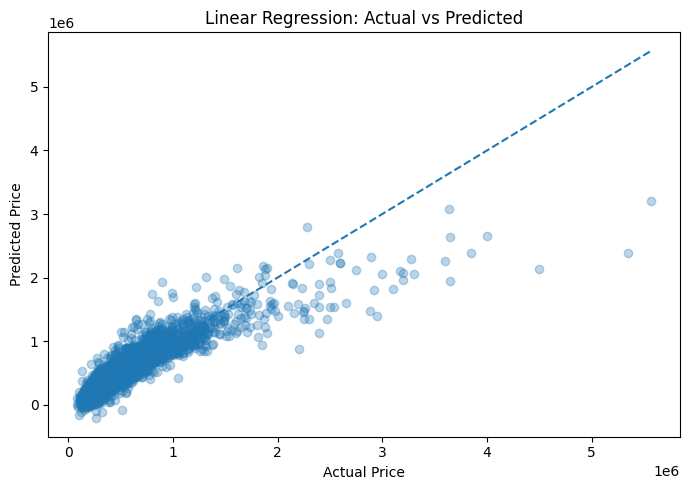

In [7]:
# ==========================================
# CELL 7 - ACTUAL VS PREDICTED PRICES
# ==========================================

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_test_pred, alpha=0.3)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--"
)

plt.tight_layout()
plt.show()


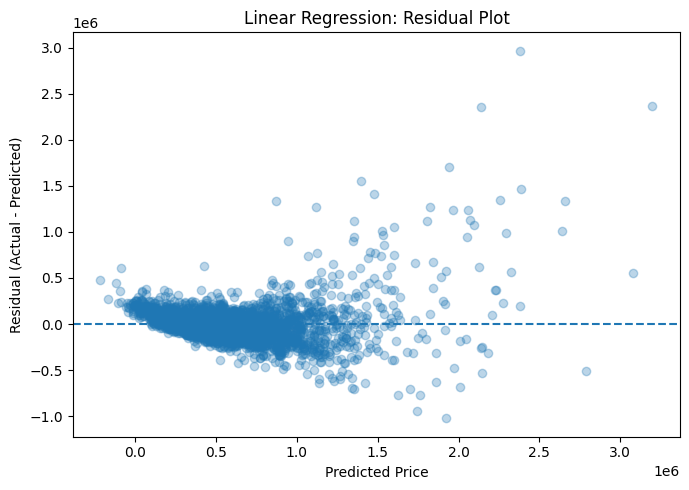

In [8]:
# ==========================================
# CELL 8 - RESIDUAL PLOT
# ==========================================

residuals = y_test - y_test_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_test_pred, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Linear Regression: Residual Plot")

plt.tight_layout()
plt.show()


In [9]:
# ==========================================
# CELL 9 - FINAL BASELINE SUMMARY
# ==========================================

summary = pd.DataFrame({
    "Model": ["Linear Regression"],
    "Train R2": [train_r2],
    "Test R2": [test_r2],
    "Test MAE": [test_mae],
    "Test RMSE": [test_rmse],
    "R2 Gap": [r2_gap]
})

display(summary.round(4))



,Model,Train R2,Test R2,Test MAE,Test RMSE,R2 Gap
0,Linear Regression,0.7928,0.7911,102711.6523,177708.0903,0.0017



Use the TEST results above in the group's final model-comparison table.


## Conclusion

Linear Regression was implemented as an additional baseline model to provide a reference point for comparison with the other machine learning models.

The model achieved a test R² of **0.7911**, with an MAE of **102,711.65** and an RMSE of **177,708.09**. The training R² of **0.7928** and test R² of **0.7911** were very close, with a difference of only **0.0017**, indicating that the model generalizes consistently to unseen data without clear evidence of overfitting.

These results provide a baseline against which the performance of the more advanced models can be compared.
